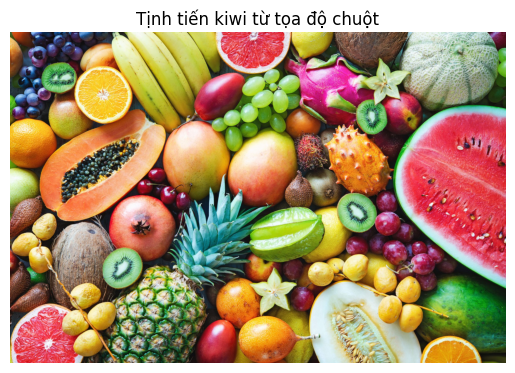

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread("colorful-ripe-tropical-fruits.jpg")
img_result = img.copy()

# Tọa độ trái kiwi từ chuột (208, 191)
x1, x2 = 173, 243
y1, y2 = 156, 226

# Cắt kiwi
kiwi = img[y1:y2, x1:x2]

# Tịnh tiến sang phải 30px
new_x1 = x1 + 30
new_x2 = x2 + 30

# Gán kiwi vào vị trí mới
img_result[y1:y2, new_x1:new_x2] = kiwi

# Hiển thị ảnh
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title("Tịnh tiến kiwi từ tọa độ chuột")
plt.axis("off")
plt.show()






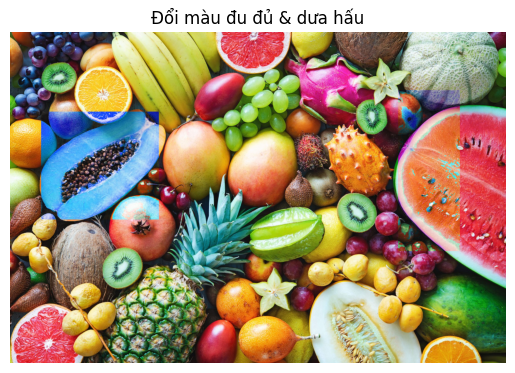

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread("colorful-ripe-tropical-fruits.jpg")
img_result = img.copy()

# Hàm đổi màu
def change_hue(region, delta_hue=90):
    hsv = cv2.cvtColor(region, cv2.COLOR_BGR2HSV)
    hsv[..., 0] = (hsv[..., 0] + delta_hue) % 180
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Đổi màu đu đủ
img_result[340:801, 133:636] = change_hue(img[340:801, 133:636])

# Đổi màu dưa hấu
img_result[248:936, 1658:1922] = change_hue(img[248:936, 1658:1922])

# Hiển thị kết quả
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title("Đổi màu đu đủ & dưa hấu")
plt.axis("off")
plt.show()







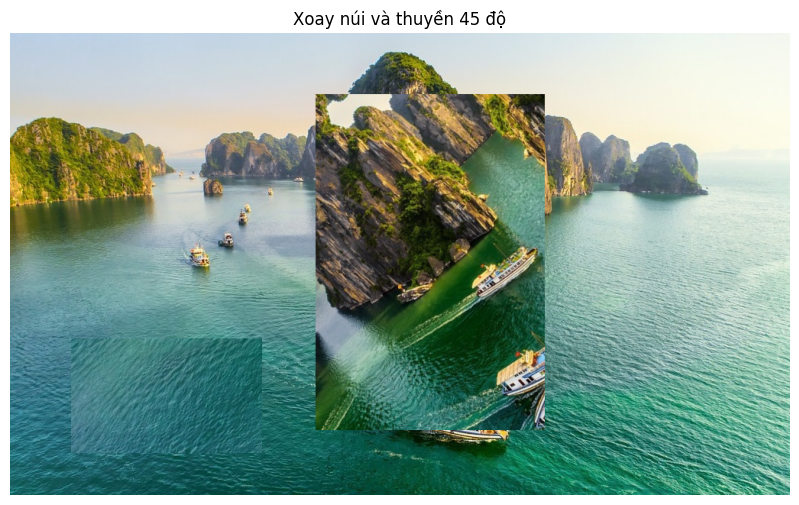

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread("quang_ninh.jpg")
img_result = img.copy()

# Hàm xoay ảnh
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    return rotated

# Núi giữa ảnh
y1_mountain, y2_mountain = 80, 520
x1_mountain, x2_mountain = 400, 700

# Thuyền lớn dưới ảnh
y1_boat, y2_boat = 400, 550
x1_boat, x2_boat = 80, 330

# Xử lý núi
mountain = img[y1_mountain:y2_mountain, x1_mountain:x2_mountain]
rotated_mountain = rotate_image(mountain, 45)
img_result[y1_mountain:y2_mountain, x1_mountain:x2_mountain] = rotated_mountain

# Xử lý thuyền
boat = img[y1_boat:y2_boat, x1_boat:x2_boat]
rotated_boat = rotate_image(boat, 45)
img_result[y1_boat:y2_boat, x1_boat:x2_boat] = rotated_boat

# Hiển thị kết quả
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title("Xoay núi và thuyền 45 độ")
plt.axis("off")
plt.show()
cv2.imwrite("quang_ninh_rotated.jpg", img_result)


In [13]:
import cv2
import numpy as np

# Các hàm xử lý
def translate(img, tx=50, ty=50):
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

def rotate(img, angle=45):
    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))

def scale(img, fx=1.5, fy=1.5):
    return cv2.resize(img, None, fx=fx, fy=fy, interpolation=cv2.INTER_CUBIC)

def coordinate_map(img):
    img_copy = img.copy()
    step = 100
    for y in range(0, img.shape[0], step):
        cv2.line(img_copy, (0, y), (img.shape[1], y), (255, 255, 255), 1)
        cv2.putText(img_copy, str(y), (5, y + 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    for x in range(0, img.shape[1], step):
        cv2.line(img_copy, (x, 0), (x, img.shape[0]), (255, 255, 255), 1)
        cv2.putText(img_copy, str(x), (x + 5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return img_copy

# Đọc ảnh
img1 = cv2.imread("colorful-ripe-tropical-fruits.jpg")
img2 = cv2.imread("quang_ninh.jpg")
img3 = cv2.imread("pagoda.jpg")

# Menu người dùng
print("\n=== MENU ===")
print("T - Tịnh tiến")
print("X - Xoay")
print("P - Phóng to")
print("H - Thu nhỏ")
print("C - Hiện bản đồ toạ độ")
print("======================")
choice = input("Nhập lựa chọn (T/X/P/H/C): ").strip().upper()

img_choice = input("Chọn ảnh (1: fruits, 2: quang_ninh, 3: pagoda): ").strip()
if img_choice == '1':
    img_selected = img1
elif img_choice == '2':
    img_selected = img2
elif img_choice == '3':
    img_selected = img3
else:
    print("❌ Ảnh không hợp lệ!")
    exit()

# Thực hiện xử lý
if choice == "T":
    result = translate(img_selected, tx=30, ty=30)
elif choice == "X":
    result = rotate(img_selected, angle=45)
elif choice == "P":
    result = scale(img_selected, fx=1.5, fy=1.5)
elif choice == "H":
    result = scale(img_selected, fx=0.5, fy=0.5)
elif choice == "C":
    result = coordinate_map(img_selected)
else:
    print("❌ Lựa chọn không hợp lệ!")
    exit()

# Hiển thị và lưu
cv2.imshow("Kết quả", result)
cv2.imwrite("interactive_result.jpg", result)
cv2.waitKey(0)
cv2.destroyAllWindows()



=== MENU ===
T - Tịnh tiến
X - Xoay
P - Phóng to
H - Thu nhỏ
C - Hiện bản đồ toạ độ


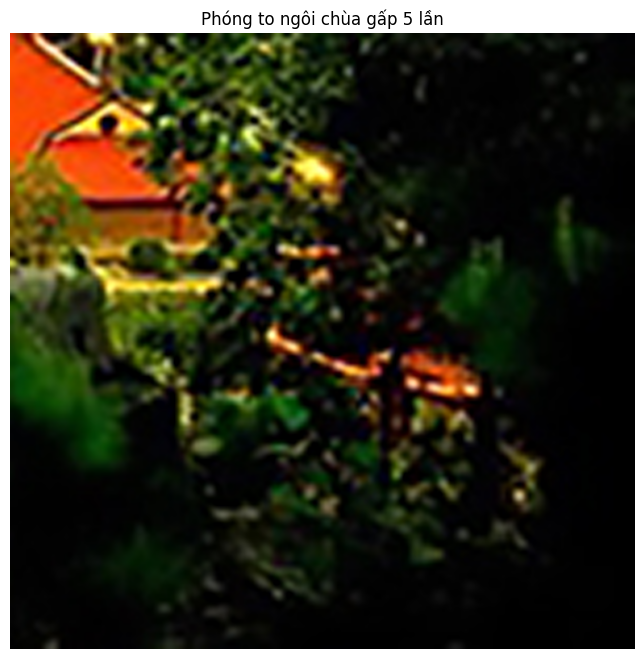

True

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread("pagoda.jpg")
img_result = img.copy()

# Hàm phóng to
def scale_image(image, fx=1.0, fy=1.0):
    return cv2.resize(image, (0, 0), fx=fx, fy=fy, interpolation=cv2.INTER_CUBIC)

# Tọa độ chính xác vùng ngôi chùa
y1, y2 = 200, 400
x1, x2 = 450, 600

# Cắt vùng chùa
pagoda = img[y1:y2, x1:x2]

# Phóng to lên 5 lần
scaled_pagoda = scale_image(pagoda, fx=5, fy=5)

# Hiển thị kết quả
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(scaled_pagoda, cv2.COLOR_BGR2RGB))
plt.title("Phóng to ngôi chùa gấp 5 lần")
plt.axis("off")
plt.show()

cv2.imwrite("pagoda_scaled.jpg", scaled_pagoda)
